In [17]:
import pandas as pd
import matplotlib.pyplot as plt

def load_data(file_name: str) -> pd.DataFrame:
    """
    Loads the raw SEN Excel file.

    Returns:
        pandas DataFrame containing the raw SEN data
    """
    return pd.read_excel(file_name)


def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cleans and prepares the SEN dataset.

    - parses the Data column as datetime
    - converts MW columns to numeric values
    - removes rows with invalid dates
    - removes duplicates
    - sorts observations chronologically
    """

    df = df.copy()

    df["Data"] = pd.to_datetime(
        df["Data"],
        dayfirst=True,
        errors="coerce"
    )

    numeric_columns = df.columns.drop("Data")

    for column in numeric_columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    df = df.dropna(subset=["Data"])
    df = df.drop_duplicates()
    df = df.sort_values("Data").reset_index(drop=True)

    return df

def save_data(df: pd.DataFrame, file_name: str) -> None:
    """
    Saves the cleaned SEN dataset as CSV.
    """
    df.to_csv(file_name, index=False)

In [18]:
raw_df = load_data("../data/raw/Grafic_SEN_2025.xlsx")

df = clean_data(raw_df)

df["SarcinaReziduala[MW]"] = (
    df["Consum[MW]"]
    - df["Eolian[MW]"]
    - df["Foto[MW]"]
)

df["Ora"] = df["Data"].dt.hour

df["Rampa[MW]"] = (
    df["SarcinaReziduala[MW]"]
    - df["SarcinaReziduala[MW]"].shift(1)
)

save_data(
    df,
    "../data/processed/sen_2025_clean.csv"
)

c:\Users\albaa\Desktop\my stuff\Lucru\MBK Energy\mbk-sen-eda\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


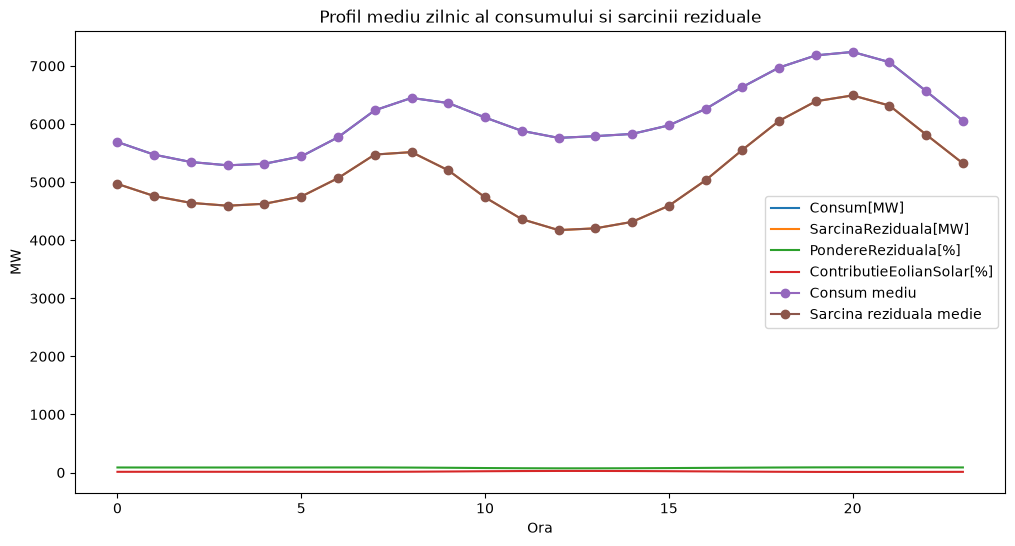

Consum mediu: 6113 MW
Sarcina reziduala medie: 5124 MW
Pondere reziduala: 83.8%
Contributie eolian + solar: 16.2%
Minim mediu al sarcinii reziduale la pranz: 4174 MW, la ora 12
Maxim mediu al sarcinii reziduale seara: 6493 MW, la ora 20


In [19]:
# Q1 Cum arată sarcina reziduală (consum total − eolian − solar) pe parcursul zilei și cât trebuie completat de producția convențională?

# Profilul mediu pe fiecare ora a zilei
hourly_profile = df.groupby("Ora")[
    ["Consum[MW]", "SarcinaReziduala[MW]"]
].mean()

# Ponderea din consum care ramane de acoperit dupa eolian si solar
hourly_profile["PondereReziduala[%]"] = (
    hourly_profile["SarcinaReziduala[MW]"]
    / hourly_profile["Consum[MW]"] * 100
)

hourly_profile["ContributieEolianSolar[%]"] = (
    100 - hourly_profile["PondereReziduala[%]"]
)

# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Grafic - profil mediu zilnic

hourly_profile.plot(figsize=(12, 6))

plt.plot(
    hourly_profile.index,
    hourly_profile["Consum[MW]"],
    marker="o",
    label="Consum mediu"
)

plt.plot(
    hourly_profile.index,
    hourly_profile["SarcinaReziduala[MW]"],
    marker="o",
    label="Sarcina reziduala medie"
)

plt.xlabel("Ora")
plt.ylabel("MW")
plt.title("Profil mediu zilnic al consumului si sarcinii reziduale")
plt.legend()
plt.show()

# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Indicatorii generali pentru 2025

consumption_mean = df["Consum[MW]"].mean()
residual_mean = df["SarcinaReziduala[MW]"].mean()

# Raportul dintre sarcina reziduala totala si consumul total
residual_share = (
    df["SarcinaReziduala[MW]"].sum()
    / df["Consum[MW]"].sum() * 100
)

renewable_share = 100 - residual_share


print(f"Consum mediu: {consumption_mean:.0f} MW")
print(f"Sarcina reziduala medie: {residual_mean:.0f} MW")
print(f"Pondere reziduala: {residual_share:.1f}%")
print(f"Contributie eolian + solar: {renewable_share:.1f}%")

# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Momente relevante ale profilului zilnic

midday_profile = hourly_profile.loc[11:15]
evening_profile = hourly_profile.loc[17:21]

midday_min_hour = midday_profile["SarcinaReziduala[MW]"].idxmin()
midday_min_value = midday_profile["SarcinaReziduala[MW]"].min()

evening_max_hour = evening_profile["SarcinaReziduala[MW]"].idxmax()
evening_max_value = evening_profile["SarcinaReziduala[MW]"].max()

print(
    f"Minim mediu al sarcinii reziduale la pranz: "
    f"{midday_min_value:.0f} MW, la ora {midday_min_hour}"
)

print(
    f"Maxim mediu al sarcinii reziduale seara: "
    f"{evening_max_value:.0f} MW, la ora {evening_max_hour}"
)

# Concluzie Q1:
Profilul mediu zilnic arată că sarcina reziduală variază semnificativ pe parcursul zilei. Aceasta scade în intervalul de prânz, când contribuția cumulată a producției eoliene și solare reduce necesarul rămas de acoperit, și crește din nou spre seară. În 2025, sarcina reziduală medie a fost de aproximativ 5.1 GW, reprezentând aproximativ 83% din consum, ceea ce înseamnă că eolianul și solarul au acoperit împreună aproximativ 17% din consum în această definiție a sarcinii reziduale. Necesarul rămas este cel mai redus în jurul prânzului și mai ridicat spre seară.

Cele mai mari ramp-down:
                     Data  SarcinaReziduala[MW]  IntervalMinute  Ora  \
51849 2025-12-25 17:13:14                3562.0        9.966667   17   
29835 2025-07-25 17:39:12                4292.0        9.566667   17   
24908 2025-06-21 22:13:02                5260.0       10.066667   22   
49018 2025-12-06 00:08:23                3909.0        9.983333    0   
9448  2025-03-07 09:50:40                4625.0       10.166667    9   
31620 2025-08-07 00:11:14                4554.0        9.733333    0   
38270 2025-09-22 10:05:31                3717.0       10.150000   10   
26428 2025-07-02 09:10:03                4165.0        9.883333    9   
10746 2025-03-16 08:09:51                4007.0        9.566667    8   
16962 2025-04-28 11:06:59                3312.0        9.916667   11   

       Rampa[MW]  
51849    -1218.0  
29835    -1169.0  
24908    -1061.0  
49018     -600.0  
9448      -545.0  
31620     -483.0  
38270     -466.0  
26428     -447.0  
10746     -

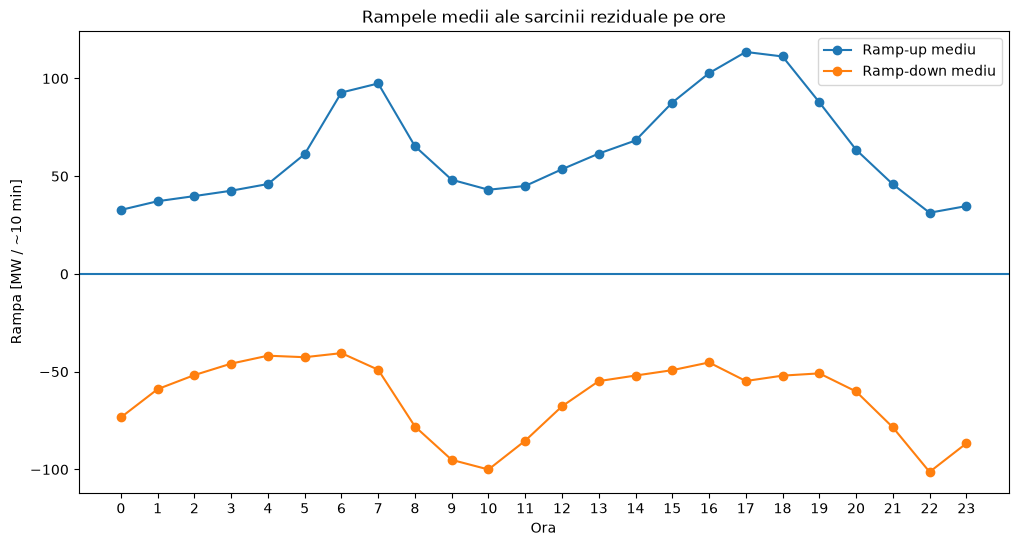

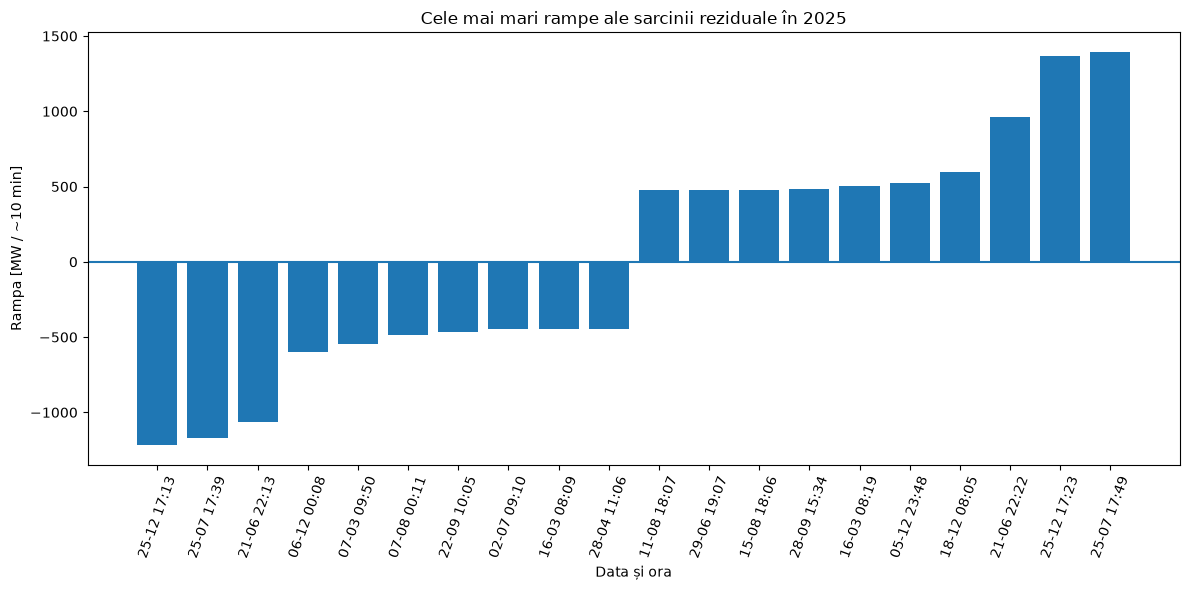

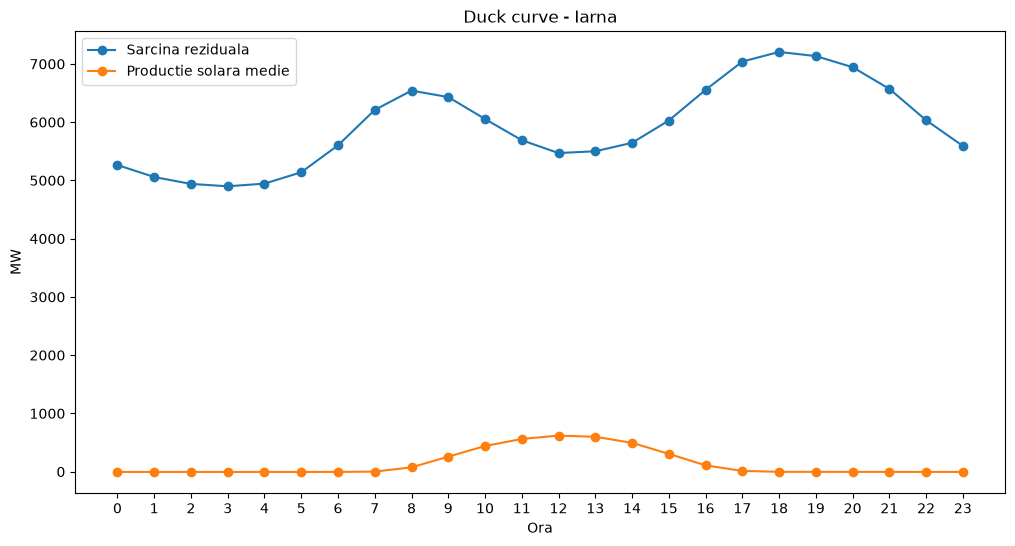

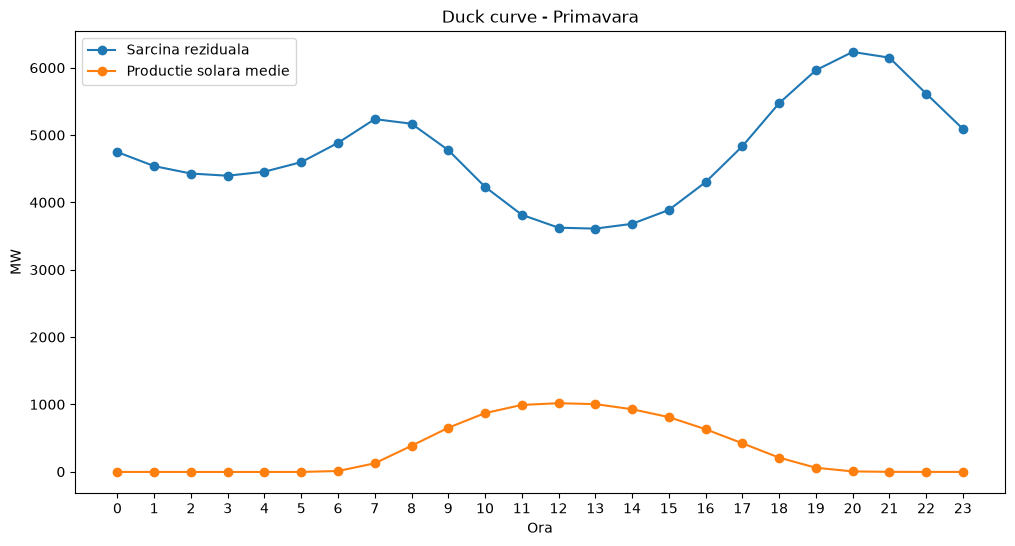

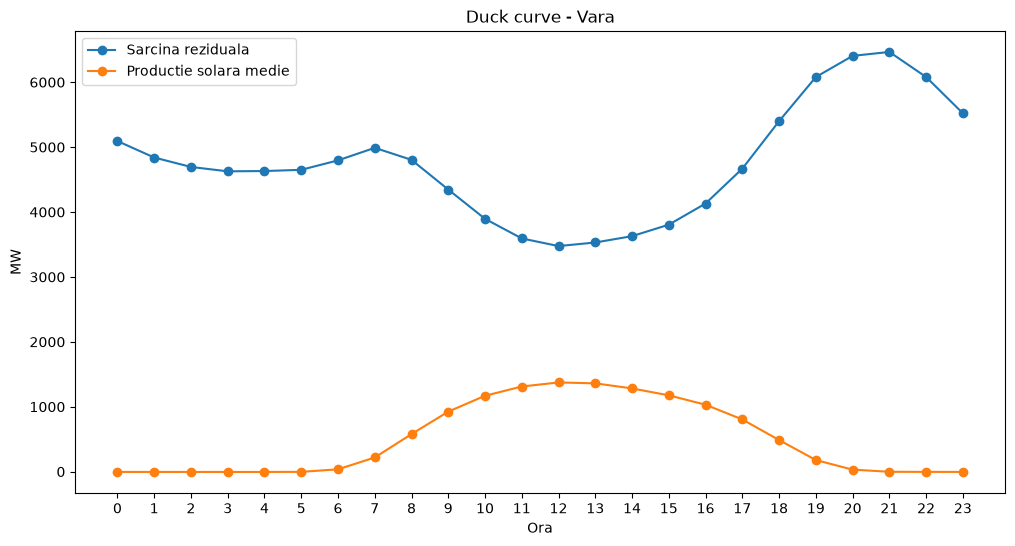

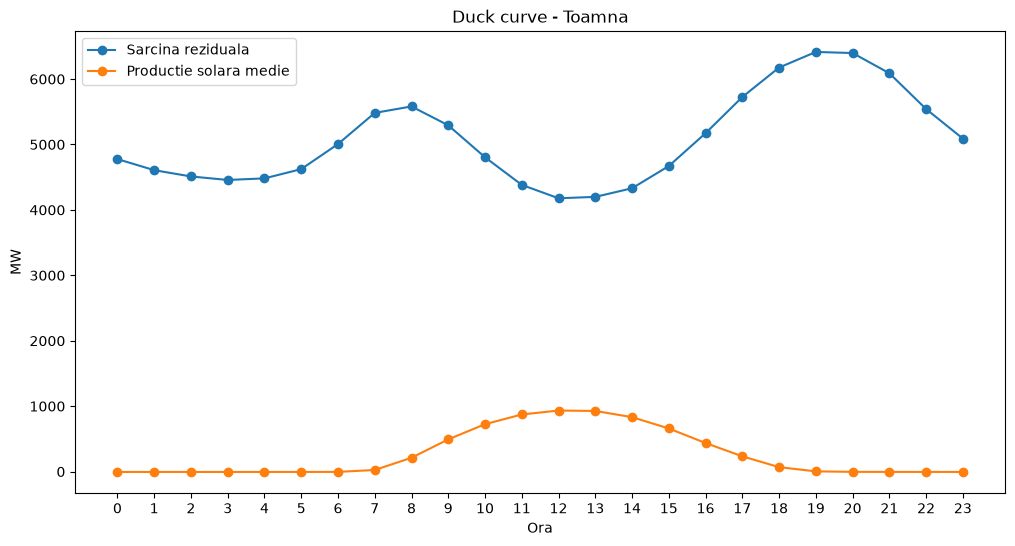

In [20]:
# Q2 - Care sunt cele mai mari rampe și la ce ore apar?

# Calculăm intervalul dintre observații, în minute
df["IntervalMinute"] = (
    df["Data"].diff().dt.total_seconds() / 60
)

# Calculăm rampa sarcinii reziduale
df["Rampa[MW]"] = (
    df["SarcinaReziduala[MW]"]
    - df["SarcinaReziduala[MW]"].shift(1)
)

# Păstrăm doar observațiile aflate la aproximativ 10 minute distanță
df_rampe = df[
    (df["IntervalMinute"] >= 9)
    & (df["IntervalMinute"] <= 11)
].copy()

# Cele mai mari scăderi
largest_ramp_down = df_rampe.nsmallest(10, "Rampa[MW]")

# Cele mai mari creșteri
largest_ramp_up = df_rampe.nlargest(10, "Rampa[MW]")

print("Cele mai mari ramp-down:")
print(
    largest_ramp_down[[
        "Data",
        "SarcinaReziduala[MW]",
        "IntervalMinute",
        "Ora",
        "Rampa[MW]"
    ]]
)

print()

print("Cele mai mari ramp-up:")
print(
    largest_ramp_up[[
        "Data",
        "SarcinaReziduala[MW]",
        "IntervalMinute",
        "Ora",
        "Rampa[MW]"
    ]]
)

# Separăm creșterile de scăderi
ramp_up = df_rampe[df_rampe["Rampa[MW]"] > 0]
ramp_down = df_rampe[df_rampe["Rampa[MW]"] < 0]

# Calculăm rampa medie pozitivă și negativă pentru fiecare oră
hourly_ramp_up = ramp_up.groupby("Ora")["Rampa[MW]"].mean()
hourly_ramp_down = ramp_down.groupby("Ora")["Rampa[MW]"].mean()

print()

print("Ramp-up mediu pe ore:")
print(hourly_ramp_up)

print()

print("Ramp-down mediu pe ore:")
print(hourly_ramp_down)

# Grafic 1 - Ramp-up și ramp-down mediu în funcție de oră

plt.figure(figsize=(12, 6))

plt.plot(
    hourly_ramp_up.index,
    hourly_ramp_up.values,
    marker="o",
    label="Ramp-up mediu"
)

plt.plot(
    hourly_ramp_down.index,
    hourly_ramp_down.values,
    marker="o",
    label="Ramp-down mediu"
)

plt.axhline(0)

plt.xlabel("Ora")
plt.ylabel("Rampa [MW / ~10 min]")
plt.title("Rampele medii ale sarcinii reziduale pe ore")

plt.xticks(range(24))
plt.legend()

plt.show()


# Grafic 2 - Cele mai mari rampe observate în 2025

top_ramps = pd.concat([
    largest_ramp_down,
    largest_ramp_up
]).sort_values("Rampa[MW]")

plt.figure(figsize=(12, 6))

plt.bar(
    top_ramps["Data"].dt.strftime("%d-%m %H:%M"),
    top_ramps["Rampa[MW]"]
)

plt.axhline(0)

plt.xlabel("Data și ora")
plt.ylabel("Rampa [MW / ~10 min]")
plt.title("Cele mai mari rampe ale sarcinii reziduale în 2025")

plt.xticks(rotation=70)

plt.tight_layout()
plt.show()

# Concluzie Q2: Analiza rampelor arată că sarcina reziduală prezintă cele mai puternice creșteri medii 
# în jurul orelor 17 - 18, cu valori de aproximativ 110 - 115 MW într-un interval de aproximativ 10 minute. 
# Scăderile medii cele mai accentuate apar în special în jurul orelor 9 - 10 și 22, ajungând la aproximativ 
# -100 MW / 10 minute. La nivelul întregului an 2025, cele mai extreme variații observate au fost de 
# aproximativ +1394 MW și -1218 MW într-un interval de aproximativ 10 minute. Aceste rezultate indică 
# existența unor perioade ale zilei în care sarcina reziduală se modifică rapid și sistemul trebuie să se adapteze într-un timp scurt.

################################################################################

# Există momente cu „duck curve” (scădere la prânz din cauza solarului, urcare bruscă seara)?

# Fac 4 grafuri pentru fiecare anotimp, iar pentru un anotimp in fiecare zi vad cand scade reziuduala si cand creste brusc,
# comparat cu energia solara. Practic pentru fiecare zi va fi peak foto gap rezidu si gap foto peak rezidu.

df["Anotimp"] = df["Data"].dt.month.map({
    12: "Iarna",
    1: "Iarna",
    2: "Iarna",
    3: "Primavara",
    4: "Primavara",
    5: "Primavara",
    6: "Vara",
    7: "Vara",
    8: "Vara",
    9: "Toamna",
    10: "Toamna",
    11: "Toamna"
})

hourly_foto = df.groupby(["Anotimp", "Ora"])[["SarcinaReziduala[MW]", "Foto[MW]"]].mean()

sezoane = ["Iarna", "Primavara", "Vara", "Toamna"]

for sezon in sezoane:
    sezon_data = hourly_foto.loc[sezon]

    plt.figure(figsize=(12, 6))

    plt.plot(
        sezon_data.index,
        sezon_data["SarcinaReziduala[MW]"],
        marker="o",
        label="Sarcina reziduala"
    )

    plt.plot(
        sezon_data.index,
        sezon_data["Foto[MW]"],
        marker="o",
        label="Productie solara medie"
    )

    plt.xlabel("Ora")
    plt.ylabel("MW")
    plt.title(f"Duck curve - {sezon}")
    plt.xticks(range(24))
    plt.legend()
    plt.show()

# 1. La prânz solarul ajunge la un nivel ridicat / maxim.
#                          ↓
# 2. În aceeași zonă orară sarcina reziduală are un minim local.
#                          ↓
# 3. Spre seară solarul scade.
#                          ↓
# 4. Sarcina reziduală crește din nou semnificativ.
#                          ↓
# 5. Creșterea de seară este suficient de rapidă
#    → o susții cu rampele / Q2.

# Pentru fiecare anotimp construiesc profilul mediu pe ore al
# sarcinii reziduale si al productiei solare.
# Verific daca maximul solar de la pranz coincide cu un minim
# al sarcinii reziduale si daca aceasta creste rapid spre seara.

# PRÂNZ, 11–15
# - valoarea maximă Foto
# - ora maximului Foto
# - valoarea minimă SarcinăReziduală
# - ora minimului SarcinăReziduală

# DIMINEAȚĂ, 6–10
# - nivelul maxim / reprezentativ al rezidualei

# SEARĂ, 17–21
# - nivelul maxim al rezidualei

# DIFERENȚE
# - scădere dimineață → prânz
# - creștere prânz → seară